In [1]:
import os
import torch
import numpy as np
from matplotlib import pyplot as plt
from wavediffusion.wavedata import npyDataResized
from torch.utils.data import DataLoader
from wavediffusion.model import Scaled
from wavediffusion.model_unet import myUnet
from wavediffusion.diffusion import ScheduleLogLinear, ScheduleDDPM, samples, samples_thres
from accelerate import Accelerator
from torch_ema import ExponentialMovingAverage as EMA
from torchvision import transforms as tf

%load_ext autoreload
%autoreload 2

In [2]:
file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/stokes_global/'
year = 2012
file_names = [(f'forcing_{year:04d}{i:02d}.npy') for i in range(1, 13)]

arrays = []

for fname in file_names:
    arr = np.load(os.path.join(file_path, fname))
    arrays.append(arr[:, [0,1], :, :])

hs = np.concatenate(arrays, axis=0)

In [4]:
wind = (hs[:,0]**2 + hs[:,1]**2) ** 0.5

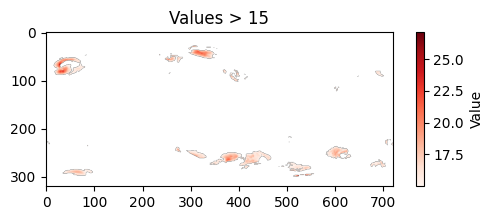

In [18]:
threshold = 15
A = wind[48]
mask = A > threshold
fig = plt.figure(figsize=[6,2])
A_masked = np.ma.masked_where(~mask, A)
plt.imshow(A_masked[::-1], cmap="Reds")
plt.colorbar(label="Value")
plt.title(f"Values > {threshold}")
plt.show()

In [ ]:
import matplotlib.patches as patches

# Example array
A = hs[0]

# Selected ranges
row_min, row_max = 140, 180     # rows
col_min, col_max = 40, 110    # columns

fig, ax = plt.subplots()
im = ax.imshow(A, origin="upper")
rect = patches.Rectangle((col_min, row_min), col_max - col_min, row_max - row_min, linewidth=2, edgecolor='red', facecolor='none')

ax.add_patch(rect); plt.show()